In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
import os
import fiona
from geopy.distance import geodesic

In [2]:
meteo_yvelines = gpd.read_file("../datasets_par_departement/meteo_yvelines.geojson")

Dimensions du DataFrame :
(2866, 112)

Info sur les types de données et les valeurs manquantes :
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2866 entries, 0 to 2865
Columns: 112 entries, hex_id to geometry
dtypes: datetime64[ns](2), float64(102), geometry(1), int64(2), object(5)
memory usage: 2.4+ MB
None


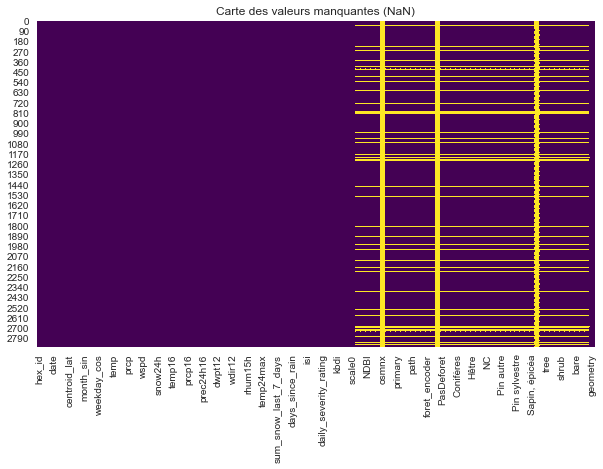


Nombre de valeurs manquantes (NaN) par colonne :
hex_id             0
id_meteo           0
duree_minutes      0
date               0
departement        0
                ... 
built            405
bare             405
snow_y           405
sinister         405
geometry           0
Length: 112, dtype: int64


In [3]:
print("Dimensions du DataFrame :")
print(meteo_yvelines.shape)

print("\nInfo sur les types de données et les valeurs manquantes :")
print(meteo_yvelines.info())

plt.figure(figsize=(10, 6))
sns.heatmap(meteo_yvelines.isnull(), cbar=False, cmap='viridis')
plt.title("Carte des valeurs manquantes (NaN)")
plt.show()

print("\nNombre de valeurs manquantes (NaN) par colonne :")
print(meteo_yvelines.isnull().sum())

In [4]:
nan_percentage = meteo_yvelines.isnull().mean() * 100

cols_to_keep = nan_percentage[nan_percentage <= 80].index

meteo_yvelines_drop = meteo_yvelines[cols_to_keep]

print("\nDimensions du DataFrame après suppression des colonnes avec plus de 80% de NaN :")
print(meteo_yvelines_drop.shape)

print("\nColonnes restantes après nettoyage :")
print(meteo_yvelines_drop.columns)


Dimensions du DataFrame après suppression des colonnes avec plus de 80% de NaN :
(2866, 109)

Colonnes restantes après nettoyage :
Index(['hex_id', 'id_meteo', 'duree_minutes', 'date', 'departement',
       'centroid_lon', 'centroid_lat', 'hour_sin', 'hour_cos', 'month_sin',
       ...
       'tree', 'grass', 'crops', 'shrub', 'flooded', 'built', 'bare', 'snow_y',
       'sinister', 'geometry'],
      dtype='object', length=109)


In [5]:
meteo_yvelines_drop = meteo_yvelines_drop.dropna()

print("\nVérification des NaN après suppression des lignes dans meteo_yvelines_drop :")
print(meteo_yvelines_drop.isnull().sum())

print("\nDimensions du DataFrame meteo_yvelines_drop après suppression des NaN :")
print(meteo_yvelines_drop.shape)


Vérification des NaN après suppression des lignes dans meteo_yvelines_drop :
hex_id           0
id_meteo         0
duree_minutes    0
date             0
departement      0
                ..
built            0
bare             0
snow_y           0
sinister         0
geometry         0
Length: 109, dtype: int64

Dimensions du DataFrame meteo_yvelines_drop après suppression des NaN :
(2448, 109)


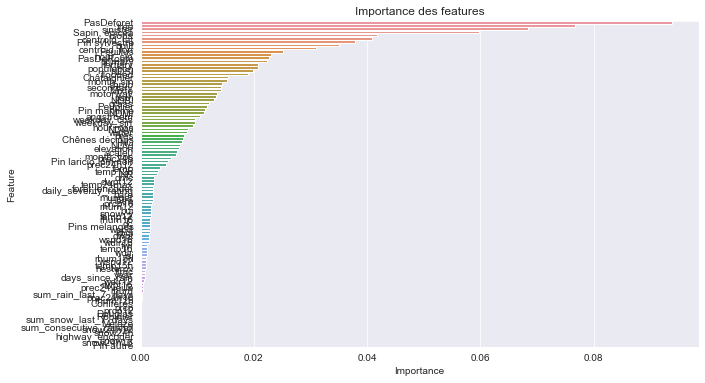

           Feature  Importance
72      PasDeforet    0.093839
92            tree    0.076688
100       sinister    0.068488
90   Sapin, épicéa    0.059688
94           crops    0.041784
1     centroid_lat    0.040833
87   Pin sylvestre    0.037832
97           built    0.035121
0     centroid_lon    0.030997
77        Feuillus    0.025206


In [6]:
X = meteo_yvelines_drop.drop(columns=['duree_minutes', 'hex_id', 'id_meteo', 'date', 'departement', 'index', 'creneau', 'geometry'])
y = meteo_yvelines_drop['duree_minutes']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importances = rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importance des features')
plt.show()

print(importance_df.head(10))

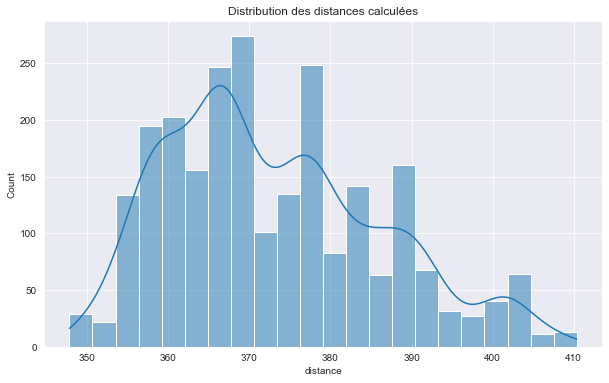

In [7]:
def haversine(lon1, lat1, lon2, lat2):
    R = 6371
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

meteo_yvelines_drop['distance'] = meteo_yvelines_drop.apply(
    lambda row: haversine(row['centroid_lon'], row['centroid_lat'], 6.5, 47.5), axis=1
)

plt.figure(figsize=(10, 6))
sns.histplot(meteo_yvelines_drop['distance'], kde=True)
plt.title('Distribution des distances calculées')
plt.show()

In [8]:
feature_importances = rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 15 des features les plus importantes :")
print(importance_df.head(15))

important_features = importance_df['Feature'].head(15).tolist()

if 'centroid_lon' not in important_features:
    important_features.append('centroid_lon')
if 'centroid_lat' not in important_features:
    important_features.append('centroid_lat')
if 'hour_cos' not in important_features:
    important_features.append('hour_cos')
if 'hour_sin' not in important_features:
    important_features.append('hour_sin')

X_selected = X[important_features]

print("\nFeatures utilisées pour l'entraînement du modèle :")
print(X_selected.columns)

Top 15 des features les plus importantes :
           Feature  Importance
72      PasDeforet    0.093839
92            tree    0.076688
100       sinister    0.068488
90   Sapin, épicéa    0.059688
94           crops    0.041784
1     centroid_lat    0.040833
87   Pin sylvestre    0.037832
97           built    0.035121
0     centroid_lon    0.030997
77        Feuillus    0.025206
2         hour_sin    0.022975
62      PasDeRoute    0.022633
64         primary    0.022358
66        tertiary    0.020748
68      population    0.020713

Features utilisées pour l'entraînement du modèle :
Index(['PasDeforet', 'tree', 'sinister', 'Sapin, épicéa', 'crops',
       'centroid_lat', 'Pin sylvestre', 'built', 'centroid_lon', 'Feuillus',
       'hour_sin', 'PasDeRoute', 'primary', 'tertiary', 'population',
       'hour_cos'],
      dtype='object')


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("\nÉvaluation du modèle :")
print(f"Mean Squared Error (MSE) : {mse}")
print(f"Mean Absolute Error (MAE) : {mae}")
print(f"R² (coefficient de détermination) : {r2}")
print(f"Root Mean Squared Error (RMSE) : {rmse}")


Évaluation du modèle :
Mean Squared Error (MSE) : 186.92425306122453
Mean Absolute Error (MAE) : 3.68734693877551
R² (coefficient de détermination) : 0.9042483851609726
Root Mean Squared Error (RMSE) : 13.672024468279178


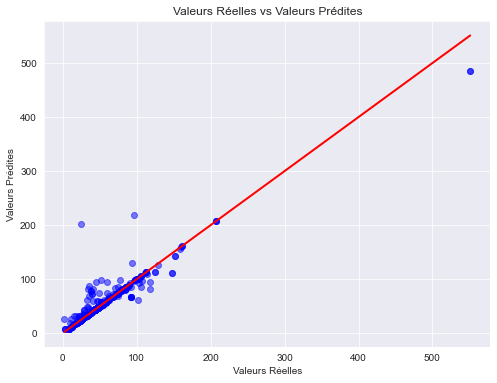

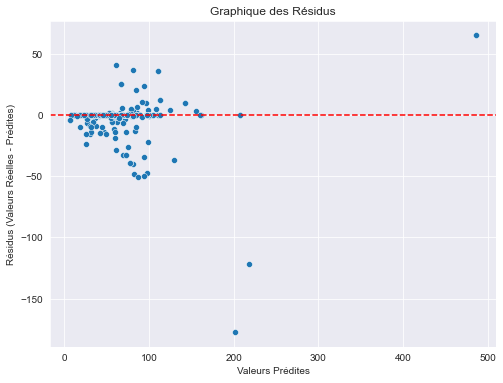

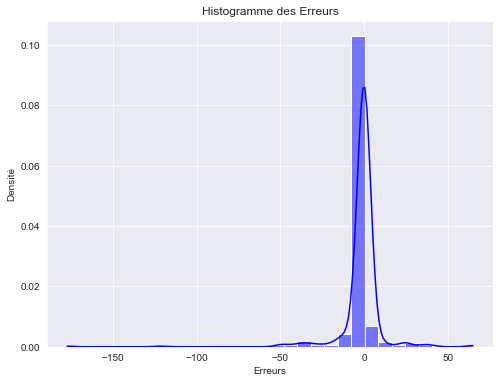

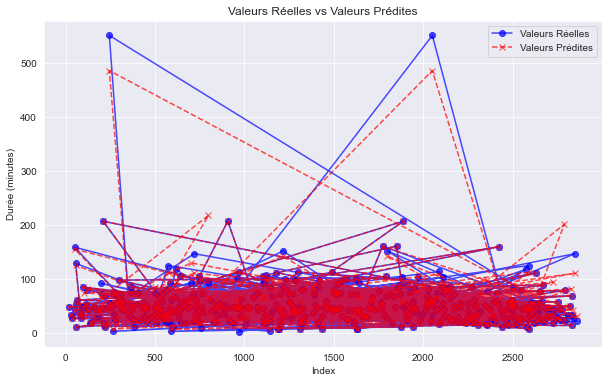

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)  # ligne parfaite
plt.title("Valeurs Réelles vs Valeurs Prédites")
plt.xlabel("Valeurs Réelles")
plt.ylabel("Valeurs Prédites")
plt.grid(True)
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Graphique des Résidus")
plt.xlabel("Valeurs Prédites")
plt.ylabel("Résidus (Valeurs Réelles - Prédites)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True, color='blue', stat='density')
plt.title("Histogramme des Erreurs")
plt.xlabel("Erreurs")
plt.ylabel("Densité")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(y_test.index, y_test, label='Valeurs Réelles', color='blue', linestyle='-', marker='o', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Valeurs Prédites', color='red', linestyle='--', marker='x', alpha=0.7)
plt.title("Valeurs Réelles vs Valeurs Prédites")
plt.xlabel("Index")
plt.ylabel("Durée (minutes)")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
model = RandomForestRegressor()

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("Meilleurs paramètres : ", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred_optimized = best_model.predict(X_test)

print("Optimized MSE:", mean_squared_error(y_test, y_pred_optimized))
print("Optimized MAE:", mean_absolute_error(y_test, y_pred_optimized))
print("Optimized R²:", r2_score(y_test, y_pred_optimized))

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Meilleurs paramètres :  {'bootstrap': True, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Optimized MSE: 173.64337986394557
Optimized MAE: 3.6806122448979592
Optimized R²: 0.9110514887405563


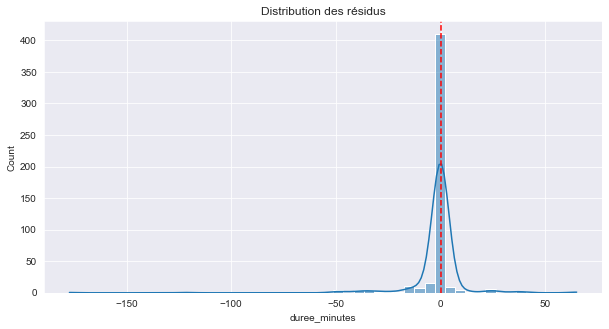

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution des résidus")
plt.show()

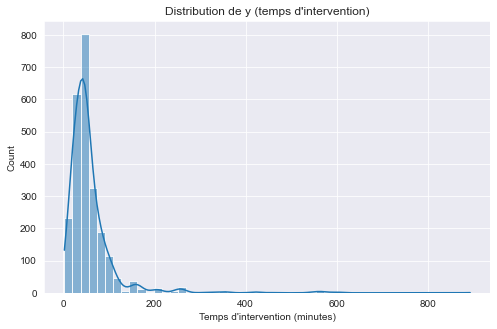

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution de y (temps d'intervention)")
plt.xlabel("Temps d'intervention (minutes)")
plt.show()

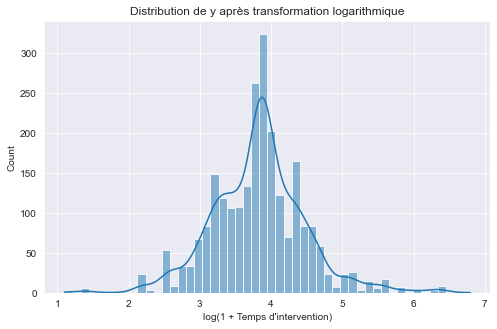

In [14]:
y_log = np.log1p(y)

plt.figure(figsize=(8,5))
sns.histplot(y_log, bins=50, kde=True)
plt.title("Distribution de y après transformation logarithmique")
plt.xlabel("log(1 + Temps d'intervention)")
plt.show()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_log, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    bootstrap=True,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_log = rf.predict(X_test)
mse_log = mean_squared_error(y_test, y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)

print(f"Log-MSE: {mse_log:.4f}")
print(f"Log-MAE: {mae_log:.4f}")
print(f"Log-R²: {r2_log:.4f}")

Log-MSE: 0.0227
Log-MAE: 0.0488
Log-R²: 0.9426


In [16]:
y_pred = np.expm1(y_pred_log)

y_test_actual = np.expm1(y_test)

mse_actual = mean_squared_error(y_test_actual, y_pred)
mae_actual = mean_absolute_error(y_test_actual, y_pred)
r2_actual = r2_score(y_test_actual, y_pred)

print(f"Actual-MSE: {mse_actual:.4f}")
print(f"Actual-MAE: {mae_actual:.4f}")
print(f"Actual-R²: {r2_actual:.4f}")

Actual-MSE: 196.6510
Actual-MAE: 3.4855
Actual-R²: 0.8993


In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestRegressor(
    random_state=42
)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score MSE (log) : {-grid_search.best_score_:.4f}")